In [3]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'
%reload_ext lab_black

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle

sns.set_context("talk")
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import ListedColormap
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter1d

from loren_frank_data_processing import (
    get_multiunit_dataframe,
    get_multiunit_dataframe2,
)

from src.load_data import load_data
from src.parameters import ANIMALS
from ZilongCode.utils import (
    bandpassfilter,
    get_zero_phase,
    get_steps,
    get_diffusion_exponent,
)

### 1, Plot example replay trajectories

In [3]:
epoch_key = ("bon", 8, 4)
data = load_data(epoch_key)

# load replay result
datafolder = (
    "/home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ThetaSweepTrajectories"
)

animal, day, epoch = epoch_key
# load the classifier results
cv_classifier_clusterless_results = xr.open_dataset(
    os.path.join(
        datafolder,
        f"{animal}_{day:02d}_{epoch:02d}_cv_classifier_clusterless_results.nc",
    )
)

# get all time slice
t = data["position_info"].index / np.timedelta64(1, "s")

Failed to load file: /media/zilong/4TB Storage HDD/ReplayTrajectoryAnalysis/Raw-Data/Bond/bonDIO08.mat
No DIO file found, using distance from well to segment trials
Failed to load file: /media/zilong/4TB Storage HDD/ReplayTrajectoryAnalysis/Raw-Data/Bond/bonDIO08.mat
No DIO file found, inferring correct inbound/outbound from task rules
Failed to load file: /media/zilong/4TB Storage HDD/ReplayTrajectoryAnalysis/Raw-Data/Bond/bonDIO08.mat
No DIO file found, using distance from well to segment trials
Failed to load file: /media/zilong/4TB Storage HDD/ReplayTrajectoryAnalysis/Raw-Data/Bond/bonDIO08.mat
No DIO file found, inferring correct inbound/outbound from task rules


In [7]:
# load multiunit times
multiunit_times = [
    get_multiunit_dataframe(tetrode_key, ANIMALS)
    for tetrode_key in data["tetrode_info"].index
]
if multiunit_times[0] is None:
    multiunit_times = [
        get_multiunit_dataframe2(tetrode_key, ANIMALS)
        for tetrode_key in data["tetrode_info"].index
    ]
# reset index in multiunit_times to seconds and replace the original multiunit_times
for i in range(len(multiunit_times)):
    indext_i = multiunit_times[i].index / np.timedelta64(1, "s")
    multiunit_times[i].index = indext_i

In [63]:
def plot_replay_trajectory(
    time_slice_replay, t, multiunit_times, results, data, figsize=(8, 3)
):

    """
    Modified from https://github.com/edeno/replicate_kenny_analysis/blob/master/notebooks/Bond_day8_Epoch4.ipynb
    by Zilong, 30/08/2023
    plor the theta sweeps in time_slice
    Input:
        time_slice_replay: the time slice to plot. a list
        t: the time index
        results: the results from the model
        data: the data from the model
        add_zero_phase_index: whether to add the zero phase index
    Output:
    """

    cmap = plt.cm.inferno
    cmap.set_bad("white", alpha=1.0)
    labelsize = 10
    ticksize = 8
    # set background color to white
    sns.set_style("white")

    fig = plt.figure(figsize=figsize, dpi=300)

    cols = len(time_slice_replay)
    gs = gridspec.GridSpec(3, cols, height_ratios=[1.5, 3, 1])

    for i in range(cols):

        time_slice_replay_i = time_slice_replay[i]

        ax3 = plt.subplot(gs[0, i])

        n_tetrodes = len(multiunit_times)

        ax3.eventplot(
            [multiunit.loc[time_slice_replay_i].index for multiunit in multiunit_times],
            color="black",
            clip_on=False,
        )

        ax3.set_yticks((1, n_tetrodes))
        ax3.set_ylim((1, n_tetrodes))
        ax3.set_ylabel("Tet. id")
        ax3.set_xticks([])
        sns.despine(ax=ax3, offset=5)
        ax3.spines["bottom"].set_visible(False)

        ax0 = plt.subplot(gs[1, i])
        # plot
        results["acausal_posterior"].sum("state", skipna=False).sel(
            time=time_slice_replay_i
        ).plot(
            x="time",
            y="position",
            robust=True,
            ax=ax0,
            cmap=cmap,
            vmin=0.0,
        )

        ax0.plot(
            data["position_info"]
            .reset_index()
            .set_index(t)
            .loc[time_slice_replay_i]
            .index,
            data["position_info"]
            .reset_index()
            .set_index(t)
            .loc[time_slice_replay_i]
            .linear_position,
            color="darkturquoise",
            linestyle="-",
            linewidth=2,
            alpha=1,
        )

        # remove all labels, ticks and spines in axi, as well as colorbars
        ax0.set_xlabel("")
        ax0.set_ylabel("")
        ax0.set_yticks([])
        ax0.set_xticks([])
        ax0.spines["right"].set_visible(False)
        ax0.spines["top"].set_visible(False)
        ax0.spines["left"].set_visible(False)
        ax0.spines["bottom"].set_visible(False)
        ax0.collections[0].colorbar.remove()

        # ax1
        ax1 = plt.subplot(gs[2, i])
        results.mental_distance_from_actual_position.sel(time=time_slice_replay_i).plot(
            x="time", ax=ax1, color="#F18D00", linewidth=1, alpha=0.8
        )
        # set y label as 'Offset' and x label empty
        ax1.set_ylabel("", fontsize=labelsize)
        ax1.set_xlabel("", fontsize=labelsize)
        # set ticks off
        ax1.set_yticks([0, 200])
        # set x ticks with time_slice_replay.start and time_slice_replay.stop without scientific notation
        ax1.set_xticks(
            [
                np.round(time_slice_replay_i.start, 1),
                np.round(time_slice_replay_i.stop, 1),
            ]
        )
        # tick labels without scientific notation
        ax1.ticklabel_format(useOffset=False, style="plain")
        # set tick labels
        ax1.set_xticklabels(
            [
                np.round(time_slice_replay_i.start - t.min(), 1),
                np.round(time_slice_replay_i.stop - t.min(), 1),
            ],
            fontsize=ticksize,
        )
        # set tick font size as ticksize
        ax1.tick_params(labelsize=ticksize)

        # add ripple times to the plot as red bars on top of the LFP
        # first get the ripples time within the time slice
        for k in data["ripple_times"].index:
            # get the ripple time
            ripple_time = data["ripple_times"].iloc[k - 1]
            start_time = ripple_time.loc["start_time"] / np.timedelta64(1, "s")
            end_time = ripple_time.loc["end_time"] / np.timedelta64(1, "s")
            # if start_time and end_time are both in the time slice. then add the ripple to the plot
            # x range is start_time to end_time, y range is [0,300]
            if (
                start_time > time_slice_replay_i.start
                and end_time < time_slice_replay_i.stop
            ):
                ax0.axvspan(
                    start_time, end_time, ymin=0, ymax=1, color="grey", alpha=0.6, lw=0
                )
                ax1.axvspan(
                    start_time, end_time, ymin=0, ymax=1, color="grey", alpha=0.3, lw=0
                )
        # add back ax1 bottom and left spines
        ax1.spines["bottom"].set_visible(True)
        ax1.spines["left"].set_visible(True)
        # set axis linewidth 1.0
        ax1.spines["bottom"].set_linewidth(1.0)
        ax1.spines["left"].set_linewidth(1.0)

        ax3.set_xlim(time_slice_replay_i.start, time_slice_replay_i.stop)
        ax0.set_xlim(time_slice_replay_i.start, time_slice_replay_i.stop)
        ax1.set_xlim(time_slice_replay_i.start, time_slice_replay_i.stop)

    # set ticks and spines
    all_axes = fig.get_axes()
    for ax in all_axes:
        ax.tick_params(labelsize=ticksize)
        ax.xaxis.label.set_size(labelsize)
        ax.yaxis.label.set_size(labelsize)
        # set axes off bottom left top and right
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()

    # save the figure to /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/Paper_figures/
    savedir = (
        "/home/zilong/Desktop/replay_trajectory_paper/Processed-Data/Paper_figures/"
    )

    savename = "Fig4_replay_trajectory_example.pdf"
    plt.savefig(savedir + savename, dpi=300, bbox_inches="tight")

In [64]:
for k in data["ripple_times"].index:
    ripple_time = data["ripple_times"].iloc[k - 1]
    start_time = ripple_time.loc["start_time"] / np.timedelta64(1, "s") - t.min()
    end_time = ripple_time.loc["end_time"] / np.timedelta64(1, "s") - t.min()
    duration = end_time - start_time
    print(start_time, end_time, duration)

3.253333333000228 3.347333333000279 0.09400000000005093
16.2800000000002 16.46733333300017 0.18733333299996957
17.89800000000014 17.96866666599999 0.07066666599985183
18.008666665999954 18.048666665999917 0.03999999999996362
18.760666665999906 18.83066666600007 0.07000000000016371
18.98066666600016 19.052000000000135 0.07133333399997355
19.594666666000194 19.670666666000216 0.07600000000002183
19.927333333000206 20.00466666600005 0.07733333299984224
20.048666665999917 20.109333332999995 0.06066666700007772
22.67266666600017 22.746666666000237 0.07400000000006912
22.76800000000003 22.805333332999908 0.03733333299987862
25.3486666660001 25.421333333000348 0.07266666700024871
25.59733333300028 25.66666666600031 0.06933333300003142
35.753999999999905 35.86133333299995 0.10733333300004233
35.99533333299996 36.050666666000325 0.05533333300036247
41.00600000000031 41.07466666600021 0.06866666599989912
42.42000000000007 42.64400000000023 0.22400000000016007
42.990666665999925 43.03466666600025

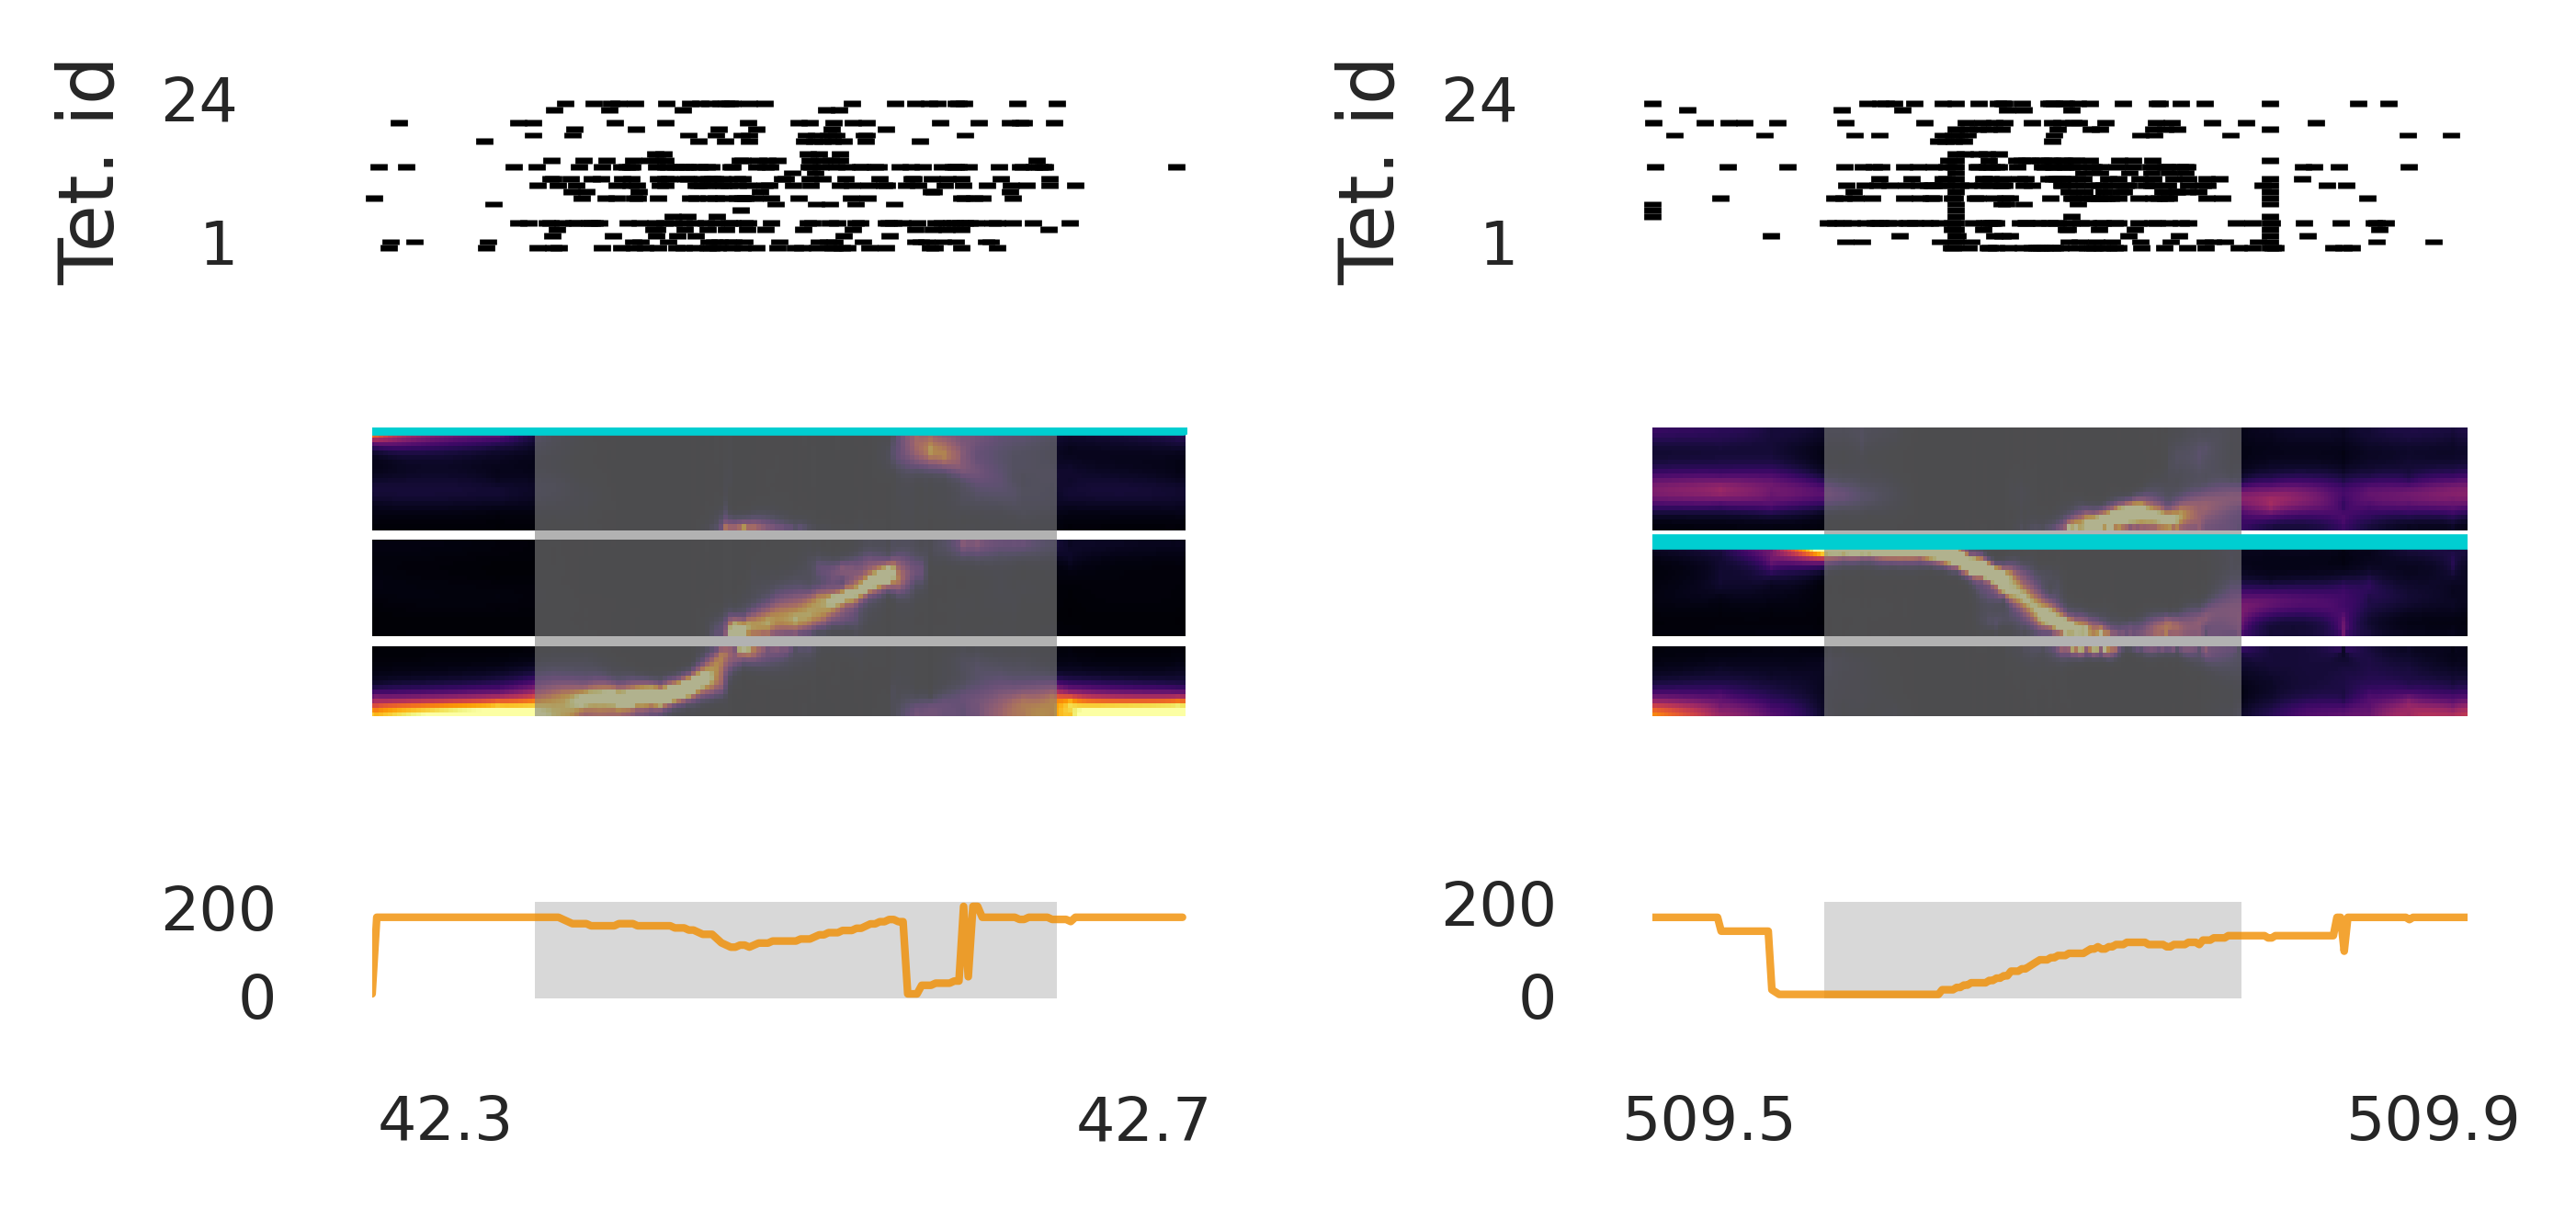

In [65]:
time_slice_1 = slice(t.min() + 42.35, t.min() + 42.7)
# time_slice_2 = slice(t.min() + 89.45, t.min() + 89.9)
time_slice_3 = slice(t.min() + 509.45, t.min() + 509.9)
# time_slice_4 = slice(t.min() + 662.8, t.min() + 663.2)
# time_slice_5 = slice(t.min() + 866.3, t.min() + 866.7)

time_slice_replay = [
    time_slice_1,
    # time_slice_2,
    time_slice_3,
    # time_slice_4,
    # time_slice_5,
]

plot_replay_trajectory(
    time_slice_replay,
    t,
    multiunit_times,
    cv_classifier_clusterless_results,
    data,
    figsize=(5, 2.5),
)

### 2, plot diffusion exponent for awake replay

In [55]:
# geneerate shuffled replay trajectories by shuffle the value under the key 'replay_trajectory'
def position_shuffling(Replay_traj):
    """
    shuffle the replay trajectory by shuffling the decoded position under each key of Replay_traj
    Input:
        Replay_traj: the replay trajectory
    Output:
        Replay_traj_shuffled: the shuffled replay trajectory
    """
    Replay_traj_shuffled = Replay_traj.copy()
    for key in Replay_traj_shuffled.keys():
        Replay_traj_shuffled[key] = np.random.permutation(Replay_traj_shuffled[key])
    return Replay_traj_shuffled

In [56]:
# load all replay trajectory from computer
replay_folder = (
    "/home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories"
)

# get all file with _traj.pkl
replay_files = [f for f in os.listdir(replay_folder) if f.endswith("_traj.pkl")]

# for each file, load the replay trajectory
all_exponent = []
all_exponent_shuffled = []
for replay_file in replay_files:
    # print("loading file: and calculate the diffusion exponent")
    print("load file: ", replay_file, " and calculate the diffusion exponent")
    with open(os.path.join(replay_folder, replay_file), "rb") as f:
        Replay_traj = pickle.load(f)
        exponent = get_diffusion_exponent(Replay_traj)
        all_exponent.append(exponent)

        # shuflle the replay trajectory
        Replay_traj_shuffled = position_shuffling(Replay_traj)
        exponent_shuffled = get_diffusion_exponent(Replay_traj_shuffled)
        all_exponent_shuffled.append(exponent_shuffled)

load file:  dav_07_07_traj.pkl  and calculate the diffusion exponent
load file:  bon_07_06_traj.pkl  and calculate the diffusion exponent
load file:  Cor_02_02_traj.pkl  and calculate the diffusion exponent
load file:  bon_07_02_traj.pkl  and calculate the diffusion exponent
load file:  bon_05_06_traj.pkl  and calculate the diffusion exponent
load file:  gov_08_04_traj.pkl  and calculate the diffusion exponent
load file:  dud_06_02_traj.pkl  and calculate the diffusion exponent
load file:  bon_03_02_traj.pkl  and calculate the diffusion exponent
load file:  Cor_07_02_traj.pkl  and calculate the diffusion exponent
load file:  dav_07_03_traj.pkl  and calculate the diffusion exponent
load file:  fra_04_02_traj.pkl  and calculate the diffusion exponent
load file:  gov_10_02_traj.pkl  and calculate the diffusion exponent
load file:  con_01_04_traj.pkl  and calculate the diffusion exponent
load file:  dav_04_02_traj.pkl  and calculate the diffusion exponent
load file:  con_03_02_traj.pkl  an

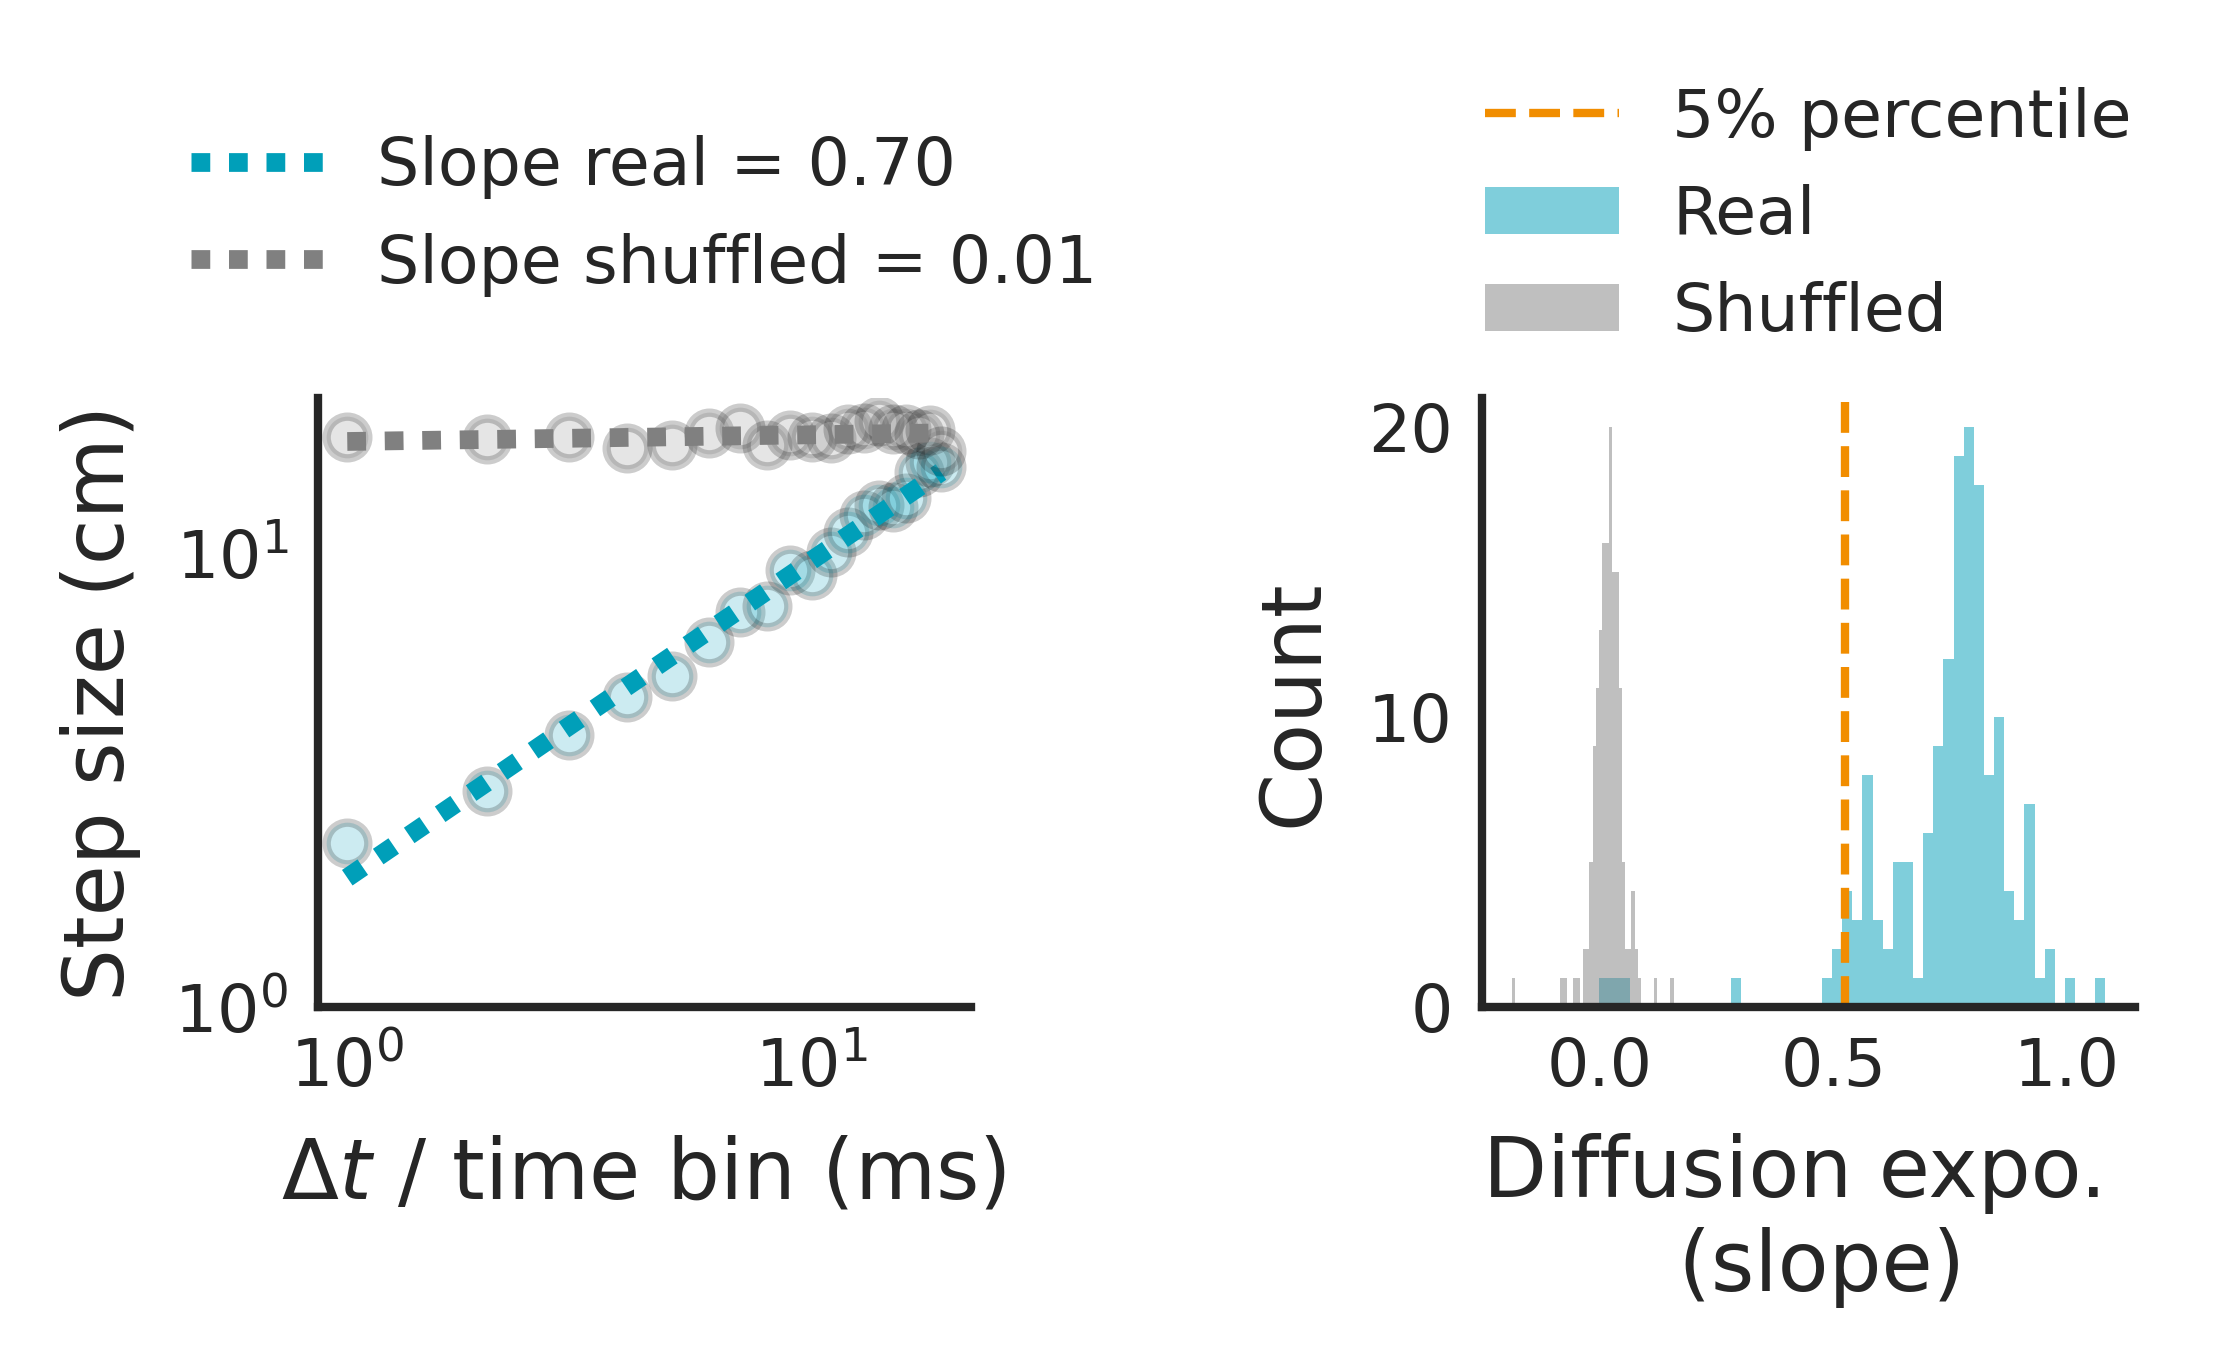

In [58]:
# load replay trajectory from the 'ReplayTrajectories'
animal, day, epoch = ("bon", 8, 4)
with open(
    os.path.join(replay_folder, f"{animal}_{day:02d}_{epoch:02d}_traj.pkl"), "rb"
) as f:
    Replay_traj = pickle.load(f)

all_timebins = np.arange(1, 20, 1)
all_avg_steps = []
for timeb in all_timebins:
    all_steps = get_steps(Replay_traj, timeb)
    # get the average step size for each time bin
    avg_step = np.mean(all_steps)
    all_avg_steps.append(avg_step)

# get the slope of the log-log plot
slope, intercept = np.polyfit(np.log(all_timebins), np.log(all_avg_steps), 1)

# get shuffled replay trajectory
Replay_traj_shuffled = position_shuffling(Replay_traj)
all_avg_steps_shuffled = []
for timeb in all_timebins:
    all_steps = get_steps(Replay_traj_shuffled, timeb)
    # get the average step size for each time bin
    avg_step = np.mean(all_steps)
    all_avg_steps_shuffled.append(avg_step)

# get the slope of the log-log plot
slope_shuffled, intercept_shuffled = np.polyfit(
    np.log(all_timebins), np.log(all_avg_steps_shuffled), 1
)


fig = plt.figure(figsize=(4, 3), dpi=300)
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
labelsize = 10
ticksize = 8
realtraj_color = "#009FB9"

# ax 1
ax1 = plt.subplot(gs[0])

# plot the log-log plot and add the slope as a lagend
# marker edge color set as black with alpha 1.0
ax1.plot(
    all_timebins,
    all_avg_steps,
    "o",
    color=realtraj_color,
    markersize=5,
    alpha=0.2,
    markeredgecolor="black",
)
# add linear regression line
ax1.plot(
    all_timebins,
    np.exp(intercept) * all_timebins**slope,
    color=realtraj_color,
    linestyle=(0, (1, 1)),
    label="Slope real = %.2f" % slope,
)

# plot the shuffled replay trajectory
ax1.plot(
    all_timebins,
    all_avg_steps_shuffled,
    "o",
    color="grey",
    markersize=5,
    alpha=0.2,
    markeredgecolor="black",
)
# add linear regression line
ax1.plot(
    all_timebins,
    np.exp(intercept_shuffled) * all_timebins**slope_shuffled,
    color="grey",
    linestyle=(0, (1, 1)),
    label="Slope shuffled = %.2f" % slope_shuffled,
)

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$\Delta t$ / time bin (ms)", fontsize=labelsize)
ax1.set_ylabel("Step size (cm)", fontsize=labelsize)
# legend with box off
ax1.legend(fontsize=ticksize, frameon=False, loc="center", bbox_to_anchor=(0.5, 1.3))
# # equal aspect ratio
# ax1.set_aspect("equal")
# set both ticks to [0,10]
ax1.set_xticks([1, 10])
ax1.set_yticks([1, 10])

# ax 2
ax2 = plt.subplot(gs[1])

# plot the distribution of all_exponent and all_exponent_shuffled
ax2.hist(
    all_exponent,
    bins=50,
    color=realtraj_color,
    alpha=0.5,
    edgecolor="none",
    label="Real",
)
ax2.hist(
    all_exponent_shuffled,
    bins=50,
    color="grey",
    alpha=0.5,
    edgecolor="none",
    label="Shuffled",
)

# mark the 5% percentile of the all_exponent as a black dashed line
ax2.axvline(
    np.percentile(all_exponent, 5),
    color="#F18D00",
    linestyle="--",
    label="5% percentile",
    linewidth=1,
)
# legend
ax2.legend(fontsize=ticksize, frameon=False, loc="center", bbox_to_anchor=(0.5, 1.3))

# xlabel and ylabel
ax2.set_xlabel("Diffusion expo. \n (slope)", fontsize=labelsize)
ax2.set_ylabel("Count", fontsize=labelsize)

# for all axes, set upper and right spine off, axis line width 1.0
all_axes = fig.get_axes()
for ax in all_axes:
    ax.tick_params(labelsize=ticksize)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    # axis line width 1.0
    ax.spines["bottom"].set_linewidth(1.0)
    ax.spines["left"].set_linewidth(1.0)
    # remove the tick bars on the left and bottom
    ax.tick_params(axis="both", which="both", length=0)

plt.tight_layout()

# save the figure to /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/Paper_figures/
savedir = "/home/zilong/Desktop/replay_trajectory_paper/Processed-Data/Paper_figures/"

savename = "Fig4_diffusion_exponent.pdf"
plt.savefig(savedir + savename, dpi=300, bbox_inches="tight")

### 3, detect sleep period

In [5]:
from src.load_data import load_sleep_data
import matplotlib.pyplot as plt
import numpy as np
from ZilongCode.utils import (
    get_theta2alpha_ratio,
    find_sleep_intervals,
    find_REM_interval,
    find_SIA_intervals,
    find_ones_intervals,
)
import pandas as pd
from scipy.ndimage import gaussian_filter
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.signal import argrelextrema
import matplotlib.gridspec as gridspec
from ZilongCode.utils import detect_sleep_periods

In [6]:
# load data
epoch_key = ("bon", 8, 3)
brain_areas = ["CA1", "CA2", "CA3"]
exclude_interneuron_spikes = True
sleepdata = load_sleep_data(
    epoch_key,
    brain_areas=brain_areas,
    exclude_interneuron_spikes=exclude_interneuron_spikes,
)

In [7]:
lowspeed_thres = 4
lowspeed_duration = (60,)
theta2alpha_thres = 1.5
REM_duration = (10,)
sleep_duration = 90
LIA_duration = 5

############################################################################################################
# 1, get candidate sleep periods with speed < 4 cm/s, preceded by 60 s with no movement > 4 cm/s.
print("Get candidate sleep periods by thresholding speed...")
speed = sleepdata["position_info"].speed
is_lowspeed, lowspeed_durations, lowspeed_intervals = find_sleep_intervals(
    speed, sleep_duration_threshold=lowspeed_duration, lowspeed_threshold=lowspeed_thres
)

############################################################################################################
# 2, get REM sleep periods with the averaged theta/alpha ratio > theta2alpha_ratio using only CA1 tetrodes
print(
    "Get REM sleep periods from all CA1 tetrodes signal by thresholding theta/alpha ratio..."
)
lfps = sleepdata["lfps"]

tetrode_info = sleepdata["tetrode_info"]
is_CA1_areas = tetrode_info.area.astype(str).str.upper().isin(["CA1"])
# find lfps in CA1 according to ishilberthilbert_brain_areas
CA1_lfps = lfps.loc[:, is_CA1_areas.values]

# initial a panda dataframe to store the theta/alpha ratio for each interval
all_theta2alpha_ratio = pd.DataFrame(index=CA1_lfps.index)
# for each column in CA1_lfps, get the theta/alpha ratio
for i in range(CA1_lfps.shape[1]):
    CA1_lfp = CA1_lfps.iloc[:, i]
    # get the theta/alpha ratio
    theta2alpha_ratio = get_theta2alpha_ratio(
        CA1_lfp, thetaband=[5, 11], alphaband=[1, 4]
    )
    # add the ratio to the theta2alpha_ratio to i column in all_theta2alpha_ratio
    all_theta2alpha_ratio[i] = theta2alpha_ratio
# get the mean ratio across all columns for each time point
mean_theta2alpha_ratio = all_theta2alpha_ratio.mean(axis=1)

# get the REM intervals
is_REM, REM_durations, REM_intervals = find_REM_interval(
    mean_theta2alpha_ratio, REMduration=REM_duration, REMthreshold=theta2alpha_thres
)

############################################################################################################
# 3, get the SIA threshod using aggregated hippocampal LFP within CA1 CA2 and CA3 tetrodes, and then find LIA periods
print("Get SIA periods from aggregated LFP signal by thresholding LFP amplitude...")
is_CA123_areas = tetrode_info.area.astype(str).str.upper().isin(["CA1", "CA2", "CA3"])
# find lfps in CA1 according to is_brain_areas
CA123_lfps = lfps.loc[:, is_CA123_areas.values]
# get the aggregated lfps
for i in range(CA123_lfps.shape[1]):
    # square the lfp signal
    CA123_lfps.iloc[:, i] = CA123_lfps.iloc[:, i] ** 2
    # Gaussian smooth the lfp signal with sigma=150, i.e. 300 ms since sampling rate is 500 Hz
    CA123_lfps.iloc[:, i] = gaussian_filter(CA123_lfps.iloc[:, i], sigma=150)
    # take square root of the lfp signal
    CA123_lfps.iloc[:, i] = np.sqrt(CA123_lfps.iloc[:, i])
    # z-score the lfp signal
    CA123_lfps.iloc[:, i] = (
        CA123_lfps.iloc[:, i] - CA123_lfps.iloc[:, i].mean()
    ) / CA123_lfps.iloc[:, i].std()
# sum the lfp over all columns
CA123_lfps_sum = CA123_lfps.sum(axis=1)
# z-score the sum lfp to get the aggregate hippocampal LFP signal
aggregate_hpc_lfp = (CA123_lfps_sum - CA123_lfps_sum.mean()) / CA123_lfps_sum.std()

# get the SIA threshold
try:
    # get the histogram of the aggregate hippocampal LFP signal
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    # Get the histogram values and bin edges
    hist_values, bin_edges, _ = ax.hist(
        aggregate_hpc_lfp, bins=100, density=True, color="k"
    )

    # fitting an bimodal distribution to the histogram
    # Define the function to fit
    def bimodal(x, mu1, sigma1, mu2, sigma2, p):
        return p * norm.pdf(x, mu1, sigma1) + (1 - p) * norm.pdf(x, mu2, sigma2)

    # Fit the data using scipy.optimize.curve_fit
    p0 = [0, 1, 0, 1, 0.5]
    params, _ = curve_fit(bimodal, bin_edges[:-1], hist_values, p0=p0)
    # Plot the fitted curve on top of the histogram
    x = np.linspace(bin_edges[0], bin_edges[-1], 1000)
    # find the local minima of the fitted curve
    local_minima = argrelextrema(bimodal(x, *params), np.less)[0]

    SIA_threshold = x[local_minima][0]

    # save the figure
    plt.savefig

    # close the figure
    plt.close(fig)
except:
    SIA_threshold = -0.67

# get the SIA intervals
is_SIA, SIA_durations, SIA_intervals = find_SIA_intervals(
    aggregate_hpc_lfp, SIA_threshold=SIA_threshold
)

############################################################################################################
# 4, get nonREM_interval from lowspeed_intervals, which equals to is_lowspeed = True and is_REM = False
print("Get nonREM periods from low speed periods and REM periods...")
is_nonREM = np.logical_and(is_lowspeed, np.logical_not(is_REM))

nonREM_int = find_ones_intervals(is_nonREM)
nonREM_intervals = []
for interval in nonREM_int:
    # store valid durations if it is more than duration seconds
    nonREM_intervals.append(
        [is_nonREM.index[interval[0]], is_nonREM.index[interval[1]]]
    )

############################################################################################################
# 5, get LIA intervals as the intervals with is_lowspeed = True and is_REM = False and is_SIA = False
print("Get LIA periods from low speed periods, REM periods and SIA periods...")
is_LIA = np.logical_and(is_lowspeed, np.logical_not(is_REM))
is_LIA = np.logical_and(is_LIA, np.logical_not(is_SIA))

LIA_int = find_ones_intervals(is_LIA)
LIA_intervals = []
LIA_durations = []
for interval in LIA_int:
    # store valid durations if it is more than duration seconds
    LIA_intervals.append([is_LIA.index[interval[0]], is_LIA.index[interval[1]]])
    LIA_duration = (
        is_LIA.index[interval[1]] - is_LIA.index[interval[0]]
    ) / np.timedelta64(1, "s")
    LIA_durations.append(LIA_duration)

############################################################################################################
# 6, get the final sleep intervals
print("Get the final sleep periods from nonREM periods and LIA periods...")
# for each nonREM_interval, if inside the interval, the length of LIA interval is more than 5 seconds, then keep this REM interval
# otherwise, set is_sleep_flags to False for that interval

# copy is_nonREM to is_sleep_flags
is_sleep_flags = is_nonREM.copy()
for nonREM_interval in nonREM_intervals:

    nonREM_duration = (nonREM_interval[1] - nonREM_interval[0]) / np.timedelta64(1, "s")

    if nonREM_duration < sleep_duration:
        # set is_sleep_flags to False for that interval
        is_sleep_flags.loc[nonREM_interval[0] : nonREM_interval[1]] = False
    else:
        # check if LIA duration is more than 5 seconds in this nonREM interval
        flag = False
        for LIA_interval in LIA_intervals:
            duration = (LIA_interval[1] - LIA_interval[0]) / np.timedelta64(1, "s")
            # if the LIA interval is within any of the nonREM_intervals and the duration is more than 5 seconds, then keep it
            if (
                (LIA_interval[0] >= nonREM_interval[0])
                and (LIA_interval[1] <= nonREM_interval[1])
                and (duration > LIA_duration)
            ):
                flag = True
                break
        if flag == False:
            # set is_sleep_flags to False for that interval
            is_sleep_flags.loc[nonREM_interval[0] : nonREM_interval[1]] = False

# get the sleep intervals
sleep_int = find_ones_intervals(is_sleep_flags)
sleep_intervals = []
sleep_durations = []
for interval in sleep_int:
    # store valid durations if it is more than duration seconds
    sleep_intervals.append(
        [is_sleep_flags.index[interval[0]], is_sleep_flags.index[interval[1]]]
    )
    sleep_duration = (
        is_sleep_flags.index[interval[1]] - is_sleep_flags.index[interval[0]]
    ) / np.timedelta64(1, "s")
    sleep_durations.append(sleep_duration)

Get candidate sleep periods by thresholding speed...
Get REM sleep periods from all CA1 tetrodes signal by thresholding theta/alpha ratio...
Get SIA periods from aggregated LFP signal by thresholding LFP amplitude...
Get nonREM periods from low speed periods and REM periods...
Get LIA periods from low speed periods, REM periods and SIA periods...
Get the final sleep periods from nonREM periods and LIA periods...


Plot the results...


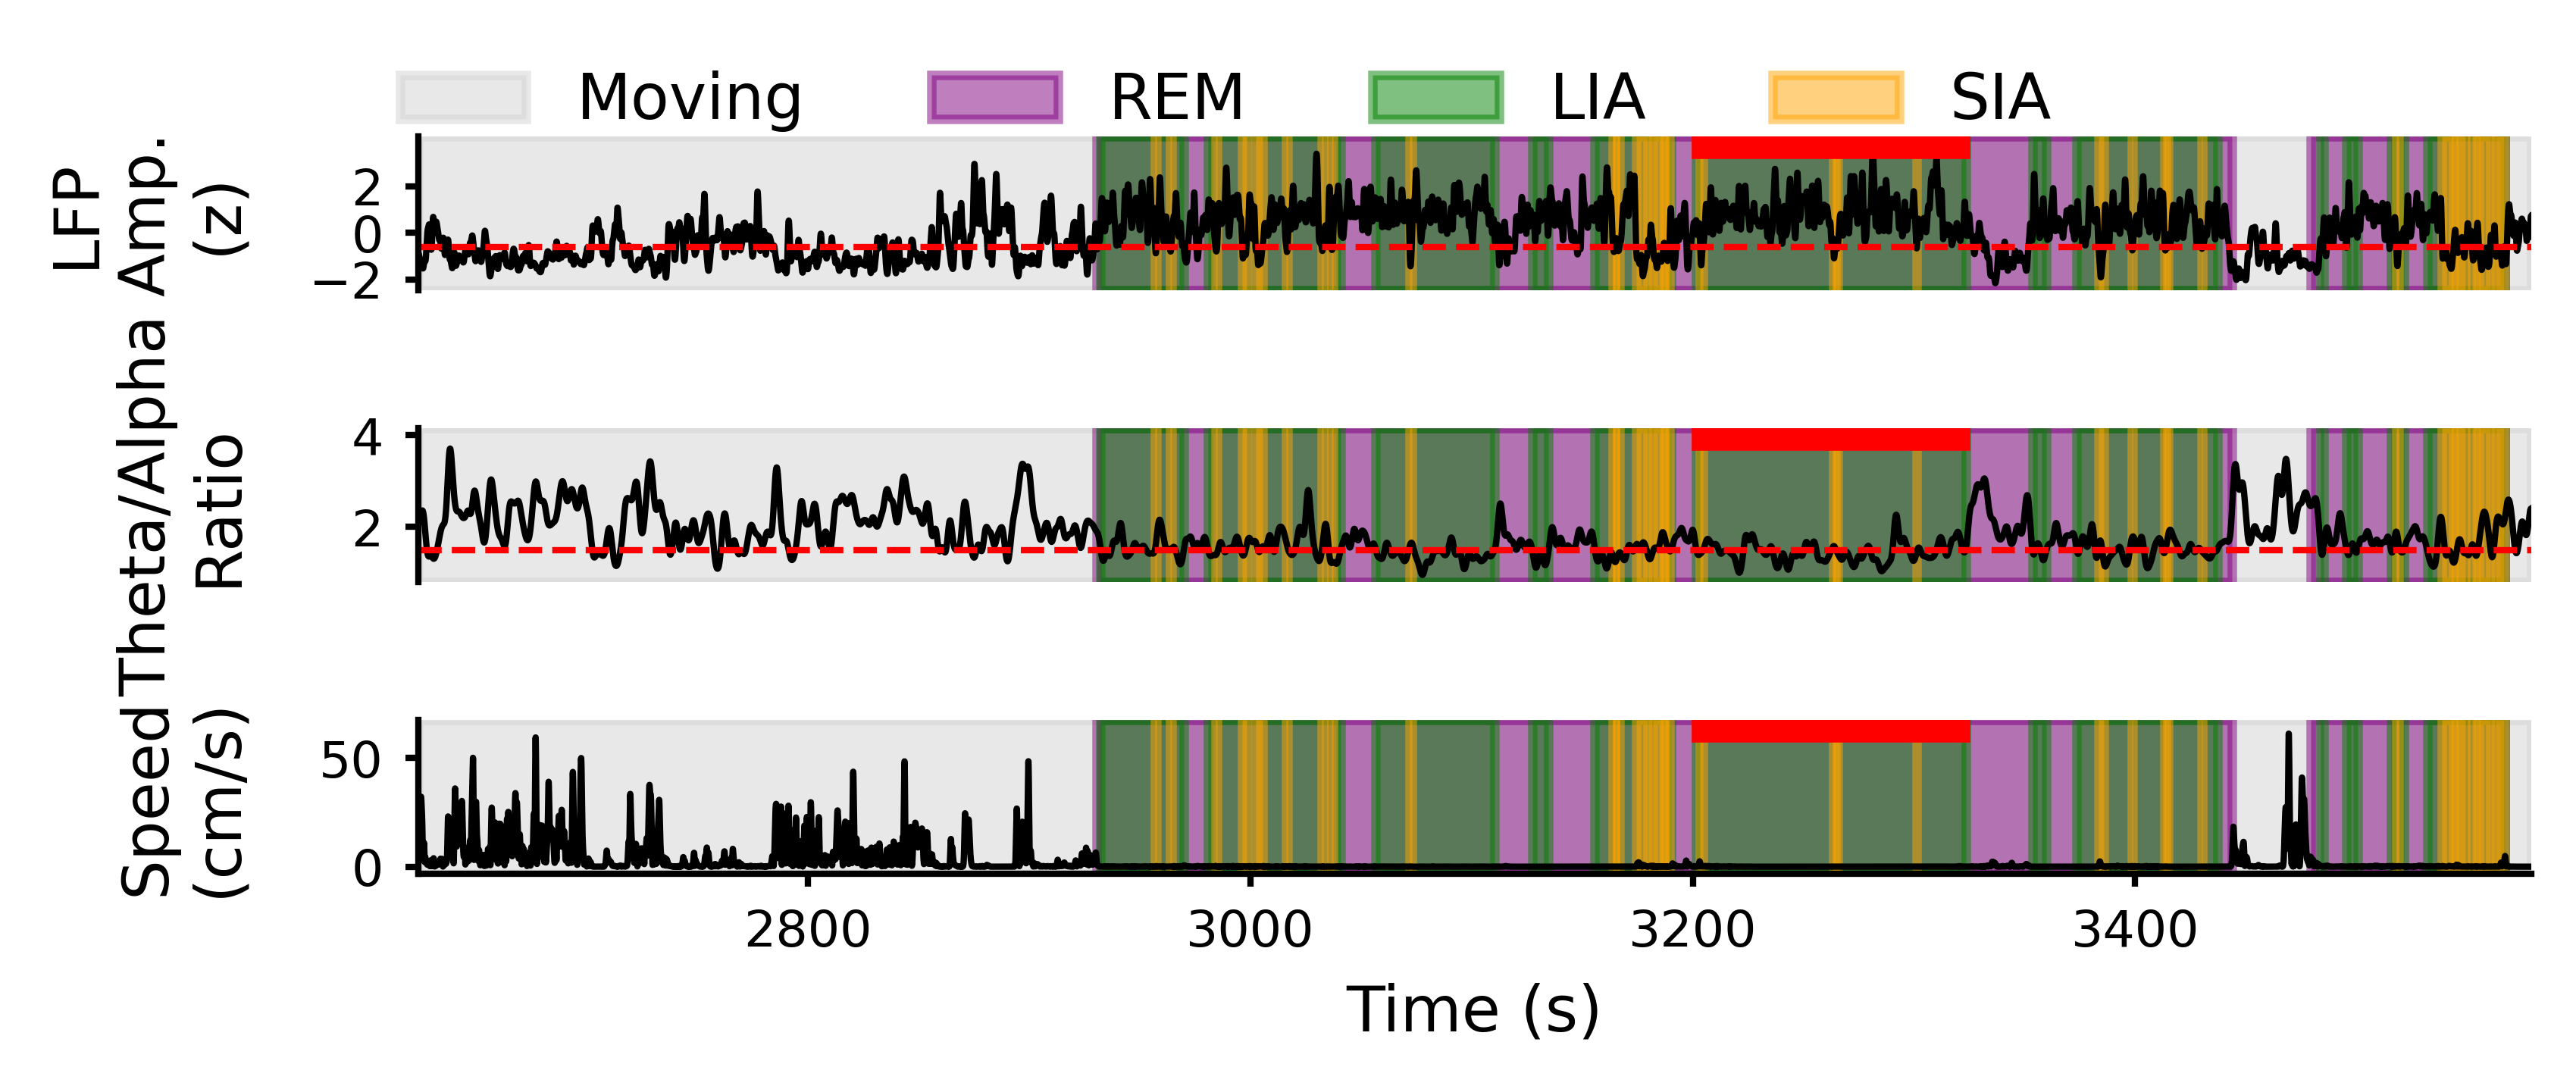

In [9]:
############################################################################################################
# 7, plot the results
print("Plot the results...")
fig = plt.figure(figsize=(6, 3), dpi=300, facecolor="white")

# make subplots height as 1:1:1:3
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1])

# set label font size
labelsize = 10
# set tick font size
ticksize = 8

# 1, plot the aggregate hippocampal LFP signal
ax0 = plt.subplot(gs[0, 0])
ax0.plot(
    aggregate_hpc_lfp.index / np.timedelta64(1, "s"),
    aggregate_hpc_lfp,
    "k",
    alpha=1,
    linewidth=1,
)
# add SIAThreshold as a horizontal line
ax0.axhline(
    y=SIA_threshold, color="r", linestyle="--", linewidth=1, label="SIA threshold"
)

ax0.set_ylabel("LFP\nAmp.\n(z)", fontsize=labelsize)
ax0.set_xticks([])
ax0.set_yticks([-2, 0, 2])
ax0.spines["bottom"].set_visible(False)

# 2, plot the theta/alpha ratio
ax1 = plt.subplot(gs[1, 0])
ax1.plot(
    mean_theta2alpha_ratio.index / np.timedelta64(1, "s"),
    mean_theta2alpha_ratio,
    "k",
    alpha=1,
    linewidth=1,
)
ax1.set_ylabel("Theta/Alpha\nRatio", fontsize=labelsize)
# add REMthreshold as a horizontal line
ax1.axhline(
    y=theta2alpha_thres, color="r", linestyle="--", linewidth=1, label="REM threshold"
)

ax1.set_xticks([])
ax1.set_yticks([0, 2, 4])
ax1.spines["bottom"].set_visible(False)

# 3, plot the speed
ax2 = plt.subplot(gs[2, 0])
ax2.plot(speed.index / np.timedelta64(1, "s"), speed, "k", alpha=1, linewidth=1)
ax2.set_xlabel("Time (s)", fontsize=labelsize)
ax2.set_ylabel("Speed\n(cm/s)", fontsize=labelsize)

# 4 add shaded area for different sleep stages to all
times = aggregate_hpc_lfp.index / np.timedelta64(1, "s")
for ax in [ax0, ax1, ax2]:
    ax.set_xlim([times[0], times[-1]])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # center align y label vertical
    ax.yaxis.set_label_coords(-0.08, 0.5)
    # axis line width 1.0
    ax.spines["bottom"].set_linewidth(1.0)
    ax.spines["left"].set_linewidth(1.0)
    # set axes tick width
    ax.tick_params(axis="both", which="both", length=2, width=1.0)

    ax.tick_params(labelsize=ticksize)

    # a, background color
    ax.axvspan(times[0], times[-1], alpha=0.5, color="lightgrey", label="Moving")

    # b, lowspeed sleep candidate as purple
    for i in range(len(lowspeed_intervals)):
        ax.axvspan(
            lowspeed_intervals[i][0] / np.timedelta64(1, "s"),
            lowspeed_intervals[i][1] / np.timedelta64(1, "s"),
            alpha=0.5,
            color="purple",
            label="REM",
        )

    # c, nonREM intervals as green
    for i in range(len(nonREM_intervals)):
        ax.axvspan(
            nonREM_intervals[i][0] / np.timedelta64(1, "s"),
            nonREM_intervals[i][1] / np.timedelta64(1, "s"),
            alpha=0.5,
            color="green",
            label="LIA",
        )

    # d, SIA intervals as orange
    for i in range(len(SIA_intervals)):
        SIA_interval = SIA_intervals[i]
        # if the SIA interval is within any of the nonREM_intervals, the plot it as orange
        for j in range(len(nonREM_intervals)):
            nonREM_interval = nonREM_intervals[j]
            if (SIA_interval[0] >= nonREM_interval[0]) and (
                SIA_interval[1] <= nonREM_interval[1]
            ):
                ax.axvspan(
                    SIA_interval[0] / np.timedelta64(1, "s"),
                    SIA_interval[1] / np.timedelta64(1, "s"),
                    alpha=0.5,
                    color="orange",
                    label="SIA",
                )
                break

# show the legend but without repeating the labels, put the legend outside the plot on the right side
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
# put legend in multiple columns at the bottom of the plot, belwo xlabel
ax0.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper right",
    bbox_to_anchor=(0.8, 1.8),
    frameon=False,
    fontsize=labelsize,
    ncol=4,
)

# e, add sleep_interval as thin black bars above axvspan (not overlapping with axvspan) at 1.1*ylim upper limit to the first plot
# get y lim for the first plot
for i in range(len(sleep_intervals)):
    sleep_interval = sleep_intervals[i]
    y_upperlim = ax0.get_ylim()[1]
    ax0.plot(
        [
            sleep_interval[0] / np.timedelta64(1, "s") + 5,
            sleep_interval[1] / np.timedelta64(1, "s") - 5,
        ],
        [y_upperlim, y_upperlim],
        "r",
        alpha=1,
        linewidth=5,
    )

    y_upperlim = ax1.get_ylim()[1]
    ax1.plot(
        [
            sleep_interval[0] / np.timedelta64(1, "s") + 5,
            sleep_interval[1] / np.timedelta64(1, "s") - 5,
        ],
        [y_upperlim, y_upperlim],
        "r",
        alpha=1,
        linewidth=5,
    )

    y_upperlim = ax2.get_ylim()[1]
    ax2.plot(
        [
            sleep_interval[0] / np.timedelta64(1, "s") + 5,
            sleep_interval[1] / np.timedelta64(1, "s") - 5,
        ],
        [y_upperlim, y_upperlim],
        "r",
        alpha=1,
        linewidth=5,
    )


plt.tight_layout()

# save the figure
animal, day, epoch = epoch_key
figdir = "/home/zilong/Desktop/AdaptiveAttractorForSequences/Figures/"
fig.savefig(
    os.path.join(figdir, f"Fig4_{animal}_{day:02d}_{epoch:02d}_sleep_periods.pdf"),
    dpi=300,
)

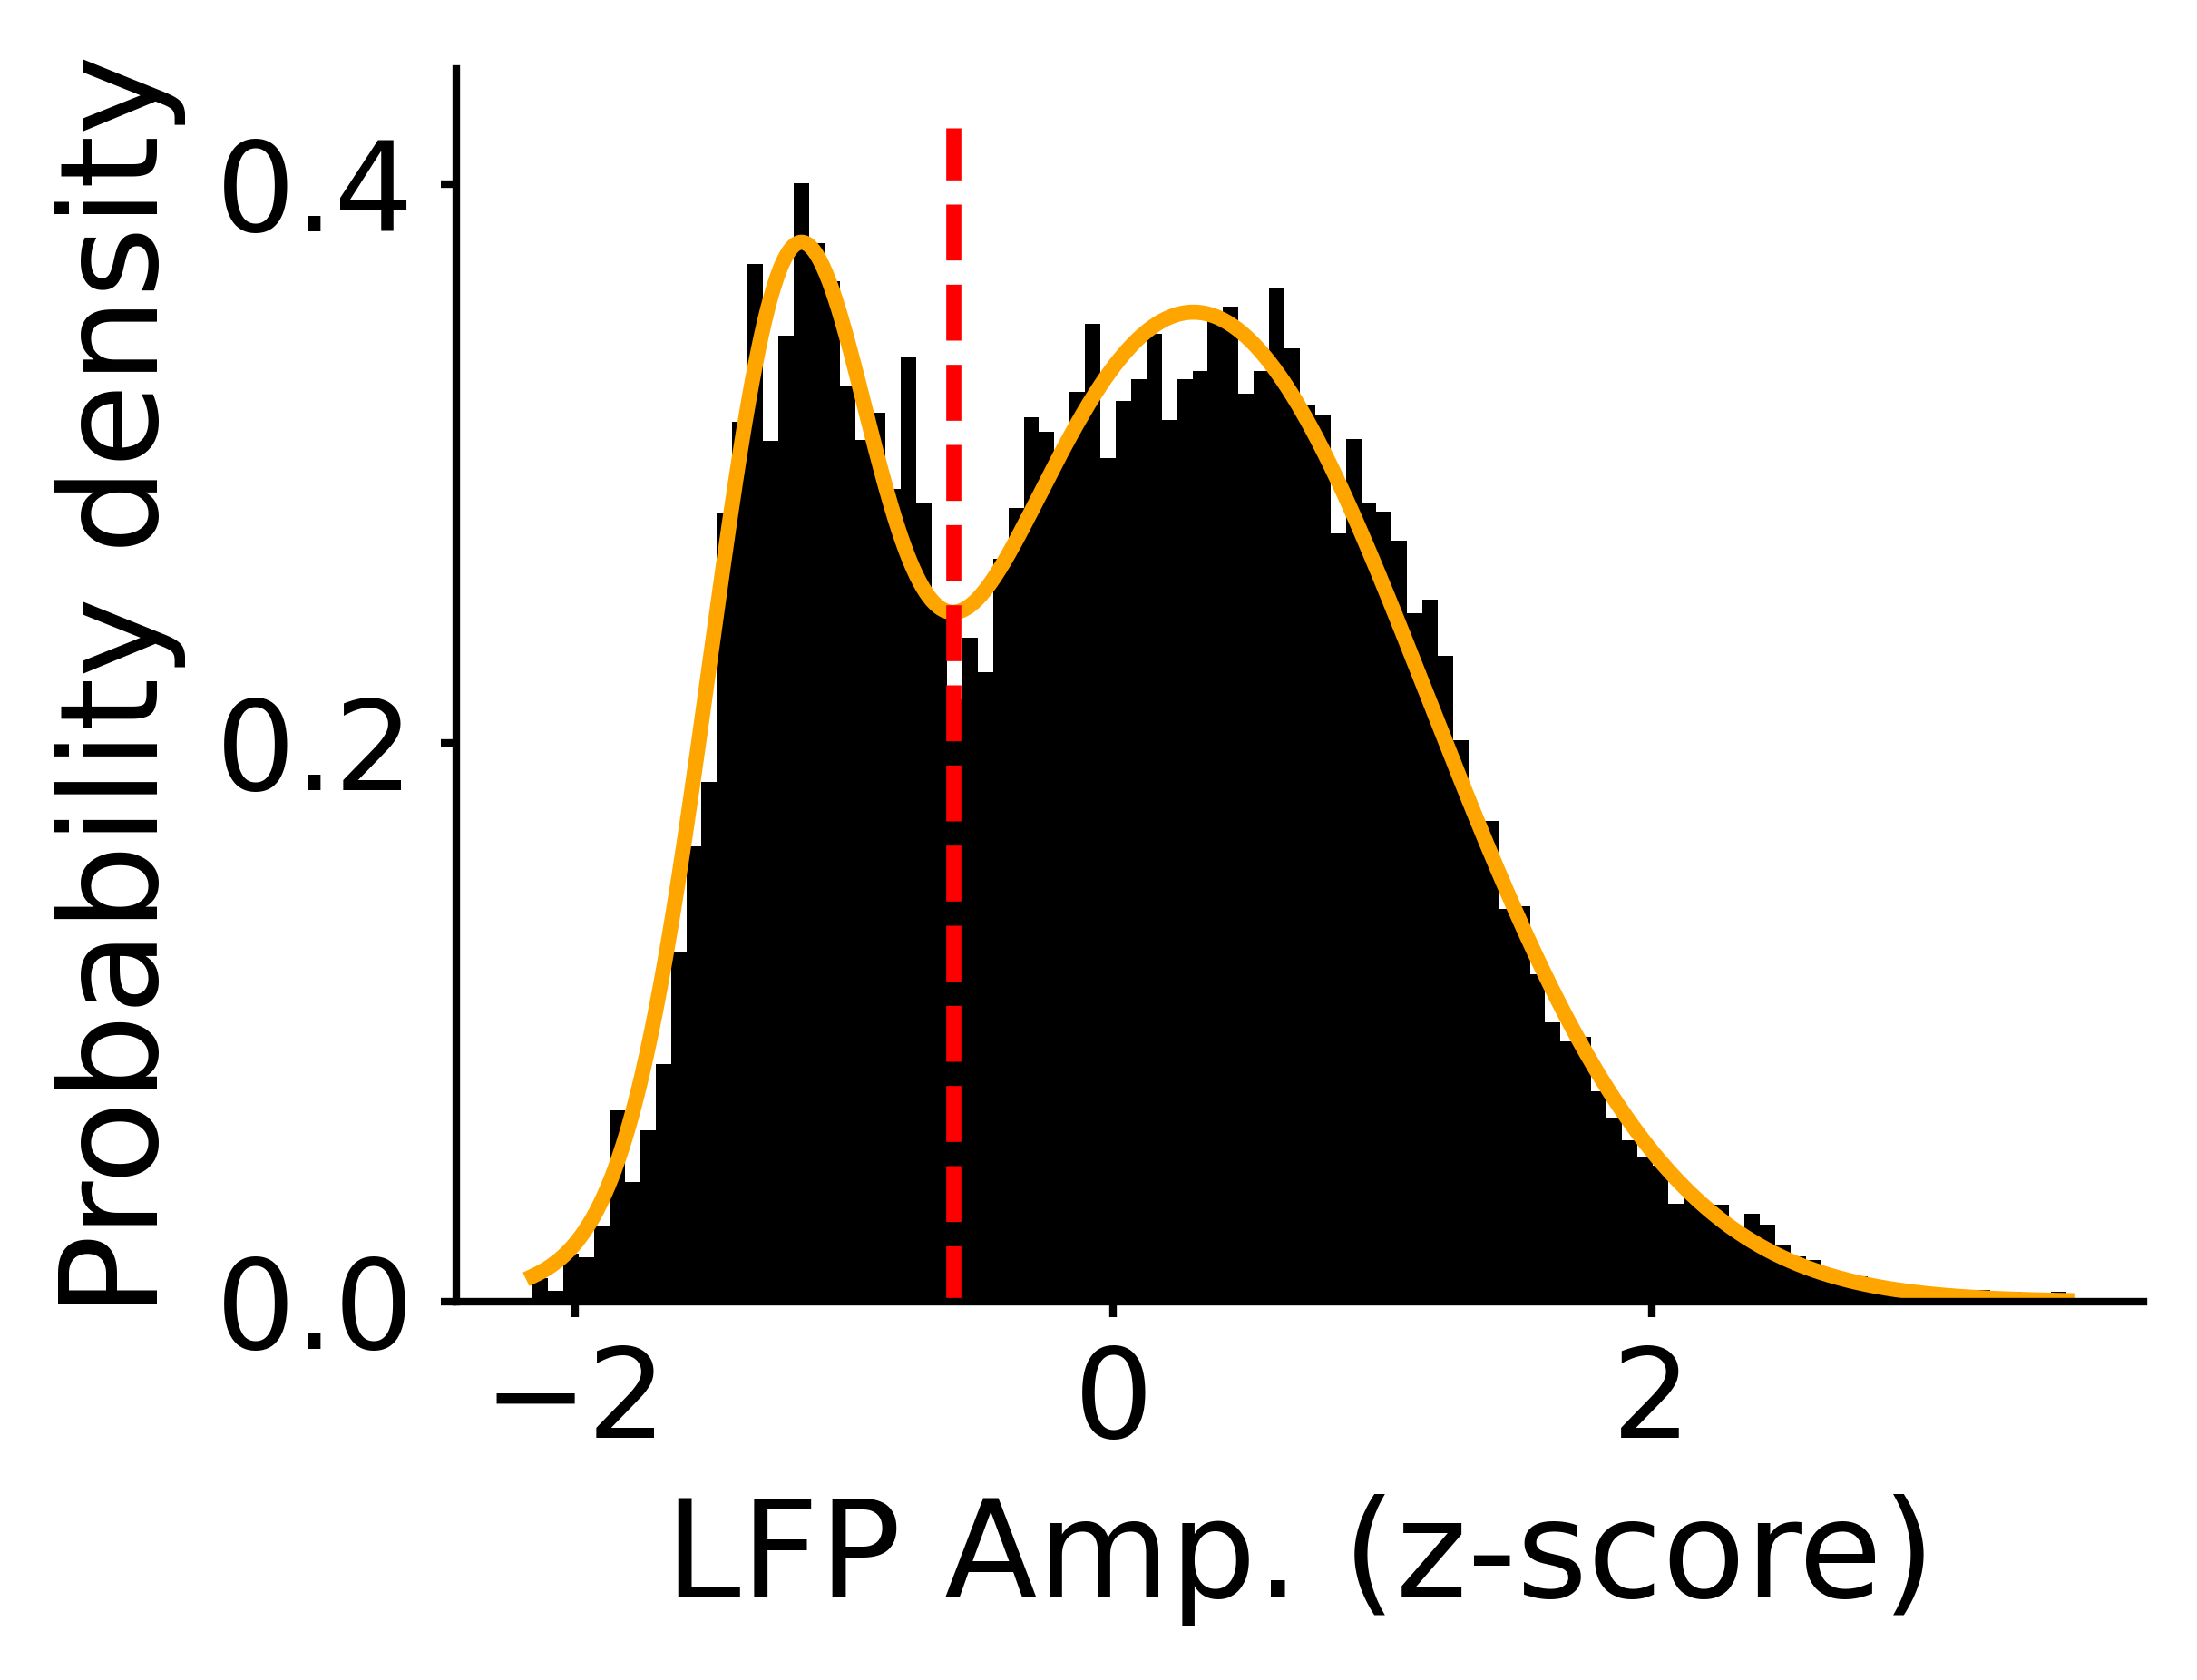

In [103]:
# 5, plot the histogram of the aggregate hippocampal LFP signal by merging gs[0,1] and gs[1,1]

fig, ax3 = plt.subplots(1, 1, figsize=(4, 3), dpi=300)

# Get the histogram values and bin edges
hist_values, bin_edges, _ = ax3.hist(
    aggregate_hpc_lfp, bins=100, density=True, color="k"
)

try:
    # fitting an bimodal distribution to the histogram
    # Define the function to fit
    def bimodal(x, mu1, sigma1, mu2, sigma2, p):
        return p * norm.pdf(x, mu1, sigma1) + (1 - p) * norm.pdf(x, mu2, sigma2)

    # Fit the data using scipy.optimize.curve_fit
    p0 = [0, 1, 0, 1, 0.5]
    params, _ = curve_fit(bimodal, bin_edges[:-1], hist_values, p0=p0)

    # Plot the fitted curve on top of the histogram
    x = np.linspace(bin_edges[0], bin_edges[-1], 1000)
    ax3.plot(x, bimodal(x, *params), "orange", linewidth=2)

    # find the local minima of the fitted curve
    local_minima = argrelextrema(bimodal(x, *params), np.less)[0]
    # add vertical lines for the local minima of y lim
    # get y lim
    ax3.plot(
        [x[local_minima][0], x[local_minima][0]],
        ax3.get_ylim(),
        "r--",
        alpha=1,
        linewidth=2,
    )
except:
    pass

ax3.set_xlabel("LFP Amp. (z-score)")
ax3.set_ylabel("Probability density")
# up and right spines are not visible
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
# axis line width 1.0
ax3.spines["bottom"].set_linewidth(1.0)
ax3.spines["left"].set_linewidth(1.0)
# axes tick width
ax3.tick_params(axis="both", which="both", length=2, width=1.0)

# save
figdir = "/home/zilong/Desktop/replay_trajectory_paper/Processed-Data/Paper_figures/"
fig.savefig(
    os.path.join(figdir, f"FigSI_{animal}_{day:02d}_{epoch:02d}_LFP_histogram.pdf"),
    dpi=300,
)

### 4, compare the diffusion exponent between awake replay and sleep replay

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm.auto import tqdm

from loren_frank_data_processing import make_epochs_dataframe, make_neuron_dataframe
from src.parameters import ANIMALS, MIN_N_NEURONS, _BRAIN_AREAS
from src.load_data import get_sleep_and_prev_run_epochs
from ZilongCode.utils import get_diffusion_exponent
from scipy.stats import ttest_rel

In [2]:
epoch_info = make_epochs_dataframe(ANIMALS)
neuron_info = make_neuron_dataframe(ANIMALS)

neuron_info = neuron_info.loc[
    (neuron_info.type == "principal")
    & (neuron_info.numspikes > 100)
    & neuron_info.area.isin(_BRAIN_AREAS)
]

n_neurons = (
    neuron_info.groupby(["animal", "day", "epoch"])
    .neuron_id.agg(len)
    .rename("n_neurons")
    .to_frame()
)

epoch_info = epoch_info.join(n_neurons)

# select only sleep epochs
is_sleep = epoch_info.type.isin(["sleep"])

is_animal = epoch_info.index.isin(
    ["bon", "fra", "gov", "dud", "con", "dav", "Cor", "egy", "cha"], level="animal"
)

# get valid epochs with is_sleep and is_animal and n_neurons > MIN_N_NEURONS
valid_epochs = epoch_info.loc[
    is_sleep & is_animal & (epoch_info.n_neurons > MIN_N_NEURONS)
]

sleep_epoch_keys, prev_run_epoch_keys = get_sleep_and_prev_run_epochs()

# get valid sleep epochs with keys only in sleep_epoch_keys
valid_sleep_epochs = valid_epochs.loc[valid_epochs.index.isin(sleep_epoch_keys)]

PROCESSED_DATA_DIR = "/home/zilong/Desktop/replay_trajectory_paper/Processed-Data"

In [3]:
SleepEXP = []
SleepIntcp = []
RunEXP = []
RunIntcp = []

for sleep_epoch_key in tqdm(valid_sleep_epochs.index, desc="epochs"):
    # current sleep epoch
    animal_sleep, day_sleep, epoch_sleep = sleep_epoch_key

    # get previous run epoch
    prev_run_epoch_key = prev_run_epoch_keys[sleep_epoch_keys.index(sleep_epoch_key)]
    animal_run, day_run, epoch_run = prev_run_epoch_key

    # for each sleep_epoch_key
    sleep_result = os.path.join(
        PROCESSED_DATA_DIR,
        "TrueSleepReplayTrajectories",
        (f"{animal_sleep}_{day_sleep:02d}_{epoch_sleep:02d}_traj.pkl"),
    )
    
    run_result = os.path.join(
        PROCESSED_DATA_DIR,
        "ReplayTrajectories",
        (f"{animal_run}_{day_run:02d}_{epoch_run:02d}_traj.pkl"),
    )
    
    # check if the file exists, if does, then extract the data
    if os.path.exists(sleep_result) and os.path.exists(run_result):

        print("Loading %s" % sleep_result)
        with open(sleep_result, "rb") as f:
            Sleep_Replay_traj = pickle.load(f)

        # extract previous run epoch results

        print("Loading %s" % run_result)
        with open(run_result, "rb") as f:
            Run_Replay_traj = pickle.load(f)

        # get exponent for sleep epoch
        sleep_exponent, sleep_intercept = get_diffusion_exponent(
            Sleep_Replay_traj, get_intercept=True
        )
        SleepEXP.append(sleep_exponent)
        SleepIntcp.append(sleep_intercept)

        # get exponent for run epoch
        run_exponent, run_intercept = get_diffusion_exponent(
            Run_Replay_traj, get_intercept=True
        )
        RunEXP.append(run_exponent)
        RunIntcp.append(run_intercept)

epochs:   1%|          | 1/116 [00:00<00:12,  9.33it/s]

Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/Cor_01_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/Cor_01_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/Cor_02_03_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/Cor_02_02_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/Cor_02_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/Cor_02_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/Cor_03_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/Cor_03_04_traj.pkl


epochs:  12%|█▏        | 14/116 [00:00<00:02, 46.09it/s]

Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/Cor_04_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/Cor_04_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/Cor_07_03_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/Cor_07_02_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/bon_03_03_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/bon_03_02_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/bon_03_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/bon_03_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/bon_03_07_traj.pkl
L

epochs:  21%|██        | 24/116 [00:00<00:02, 37.55it/s]

...

Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/dav_06_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/dav_06_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/dav_06_07_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/dav_06_06_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/dud_02_03_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/dud_02_02_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/dud_06_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/dud_06_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/egy_05_03_traj.pkl
L

epochs:  61%|██████    | 71/116 [00:01<00:01, 40.69it/s]

Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/egy_05_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/egy_05_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/egy_05_07_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/egy_05_06_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/egy_08_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/egy_08_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/fra_06_07_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/fra_06_06_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/gov_07_05_traj.pkl
L

epochs: 100%|██████████| 116/116 [00:01<00:00, 58.63it/s] 

Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/gov_08_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/gov_08_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/gov_08_07_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/gov_08_06_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/gov_09_06_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/gov_09_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/gov_11_05_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/ReplayTrajectories/gov_11_04_traj.pkl
Loading /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/TrueSleepReplayTrajectories/gov_12_07_traj.pkl
L

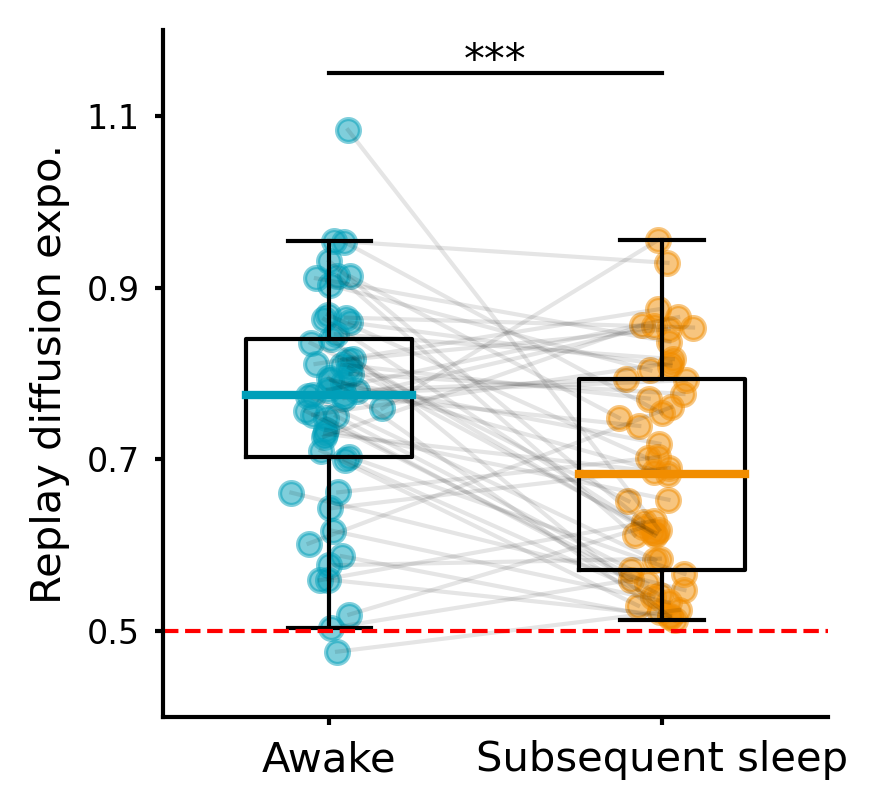

In [25]:
# barplot of SleepEXP and RunEXP in subplot 1, as well as SleepIntcp and RunIntcp in subplot 2
fig, ax = plt.subplots(1, 1, figsize=(3, 2.8), dpi=300)

labelsize = 10
ticksize = 8
# boxplot without mark outliers
bp = ax.boxplot([RunEXP, SleepEXP], positions=[0, 1], widths=0.5, showfliers=False)

# Set different colors for medians
for median, color in zip(bp["medians"], ["#009FB9", "#F18D00"]):
    median.set(color=color, linewidth=2)

# add scatter plot and add jitter for better visualization
RunX = np.zeros(len(RunEXP))+np.random.normal(0, 0.05, len(RunEXP))
ax.scatter(RunX, RunEXP, color="#009FB9", s=30, alpha=0.5)
SleepX = np.ones(len(SleepEXP))+np.random.normal(0, 0.05, len(SleepEXP))
ax.scatter(SleepX, SleepEXP, color="#F18D00", s=30, alpha=0.5)

# link paired data with a line
for i in range(len(SleepEXP)):
    # ax.plot([0, 1], [RunEXP[i], SleepEXP[i]], color="black", alpha=0.1, linewidth=1)
    ax.plot([RunX[i], SleepX[i]], [RunEXP[i], SleepEXP[i]], color="black", alpha=0.1, linewidth=1)

# add a horizontal line at y=0.5 as red
ax.axhline(y=0.5, color="red", linestyle="--", linewidth=1)

# carry out wilcoxon test
from scipy.stats import wilcoxon

stat, p = wilcoxon(RunEXP, SleepEXP)
# stat, p = ttest_rel(SleepEXP, RunEXP)

# add horizontal line link (0,1) and (1,1)
ax.plot([0, 1], [1.15, 1.15], color="black", alpha=1, linewidth=1)
# add horizontal line and stars above the line to indicate the p value
if p < 0.001:
    ax.text(0.5, 1.15, "***", fontsize=labelsize, horizontalalignment="center")
elif p < 0.01:
    ax.text(0.5, 1.15, "**", fontsize=labelsize, horizontalalignment="center")
elif p < 0.05:
    ax.text(0.5, 1.15, "*", fontsize=labelsize, horizontalalignment="center")
else:
    ax.text(
        0.5,
        1.15,
        "n.s.",
        fontsize=labelsize,
        horizontalalignment="center",
        verticalalignment="center",
    )

# add stats and p value to the title
# ax[0].set_title('Wilcoxon test: stat=%.2f, p=%.3f'%(stat, p))
# ax.set_title("t(52)=%.2f, p=%.3f" % (stat, p), fontsize=ticksize, pad=5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Awake", "Subsequent sleep"], fontsize=labelsize)
ax.set_ylabel("Replay diffusion expo.", fontsize=labelsize)
ax.set_ylim([0.4, 1.2])
# yticks as 0.5, 0.6, 0.7, 0.8, 0.9, 1.0
ax.set_yticks([0.5, 0.7, 0.9, 1.1])
# set x ticksize as labelsize y ticksize as ticksize
ax.tick_params(axis="x", labelsize=labelsize)
ax.tick_params(axis="y", labelsize=ticksize)

# spines top and right off
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# axis line width 1.0
ax.spines["bottom"].set_linewidth(1.0)
ax.spines["left"].set_linewidth(1.0)
# axes tick width
ax.tick_params(axis="both", which="both", length=2, width=1.0)

plt.tight_layout()

plt.savefig(
    "/home/zilong/Desktop/replay_trajectory_paper/Processed-Data/Paper_figures/Fig4_SleepvsAwakeExponent.pdf",
    bbox_inches="tight",
)

In [5]:
p

0.00046304923027993926